In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df=pd.read_csv('National_Stock_Exchange_of_India_Ltd.csv')

df.head()

,Symbol,Open,High,Low,LTP,Chng,% Chng,Volume (lacs),Turnover (crs.),52w H,52w L,365 d % chng,30 d % chng
0,ADANIPORTS,750,766,713.25,715,-47.45,-6.22,72.20,532.63,901,384.4,79.22,-4.65
1,ASIANPAINT,"3,101.00","3,167.35","3,091.00","3,138.00",-6.25,-0.20,10.29,322.53,"3,505.00","2,117.15",45.66,5.66
2,AXISBANK,669,674.9,660.45,661,-18.90,-2.78,102.53,684,866.9,568.4,10.19,-21.49
3,BAJAJ-AUTO,"3,370.00","3,383.50","3,320.00","3,335.00",-56.70,-1.67,3.42,114.59,"4,361.40","3,041.00",9.30,-12.05
4,BAJAJFINSV,"17,200.00","17,237.20","16,610.00","16,684.00",-684.85,-3.94,3.42,576.79,"19,325.00","8,273.70",91.38,-9.10


In [8]:
df = df.rename(columns={
    "Symbol": "Company",
    "LTP": "Price"
})
df.head()

,Company,Open,High,Low,Price,Chng,% Chng,Volume (lacs),Turnover (crs.),52w H,52w L,365 d % chng,30 d % chng
0,ADANIPORTS,750,766,713.25,715,-47.45,-6.22,72.20,532.63,901,384.4,79.22,-4.65
1,ASIANPAINT,"3,101.00","3,167.35","3,091.00","3,138.00",-6.25,-0.20,10.29,322.53,"3,505.00","2,117.15",45.66,5.66
2,AXISBANK,669,674.9,660.45,661,-18.90,-2.78,102.53,684,866.9,568.4,10.19,-21.49
3,BAJAJ-AUTO,"3,370.00","3,383.50","3,320.00","3,335.00",-56.70,-1.67,3.42,114.59,"4,361.40","3,041.00",9.30,-12.05
4,BAJAJFINSV,"17,200.00","17,237.20","16,610.00","16,684.00",-684.85,-3.94,3.42,576.79,"19,325.00","8,273.70",91.38,-9.10


In [18]:
df['Company'].value_counts().sum()

np.int64(50)

In [3]:
df.dtypes

Symbol              object
Open                object
High                object
Low                 object
LTP                 object
Chng               float64
% Chng             float64
Volume (lacs)      float64
Turnover (crs.)     object
52w H               object
52w L               object
365 d % chng       float64
30 d % chng        float64
dtype: object

In [11]:
# Convert columns to appropriate data types
columns_to_convert = ['Open', 'High', 'Low', 'Price', 'Turnover (crs.)', '52w H', '52w L']

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col].replace(',', ''), errors='coerce')

df.dtypes

Company             object
Open               float64
High               float64
Low                float64
Price              float64
Chng               float64
% Chng             float64
Volume (lacs)      float64
Turnover (crs.)    float64
52w H              float64
52w L              float64
365 d % chng       float64
30 d % chng        float64
dtype: object

In [4]:
df.isna().sum()

Symbol             0
Open               0
High               0
Low                0
LTP                0
Chng               0
% Chng             0
Volume (lacs)      0
Turnover (crs.)    0
52w H              0
52w L              0
365 d % chng       0
30 d % chng        0
dtype: int64

In [6]:
df.describe()

,Chng,% Chng,Volume (lacs),365 d % chng,30 d % chng
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,-70.133000,-2.930200,71.266600,41.203000,-5.996800
std,163.203678,2.677007,93.462062,37.358646,6.322546
min,-770.500000,-7.480000,0.300000,-16.020000,-22.080000
25%,-66.775000,-4.527500,13.472500,9.375000,-9.665000
50%,-29.975000,-3.300000,30.750000,35.860000,-5.705000
75%,-7.812500,-1.932500,99.200000,65.942500,-2.222500
max,158.400000,7.230000,517.880000,167.950000,6.360000


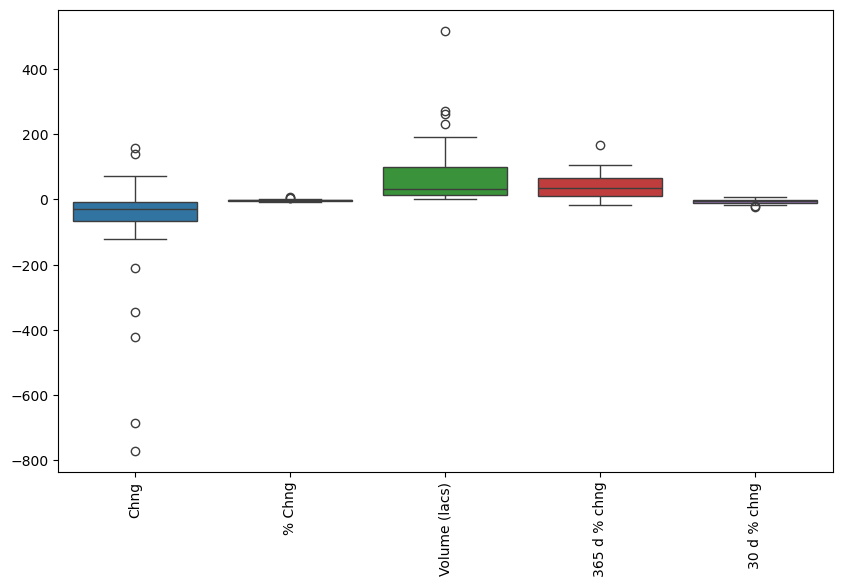

In [5]:
#outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

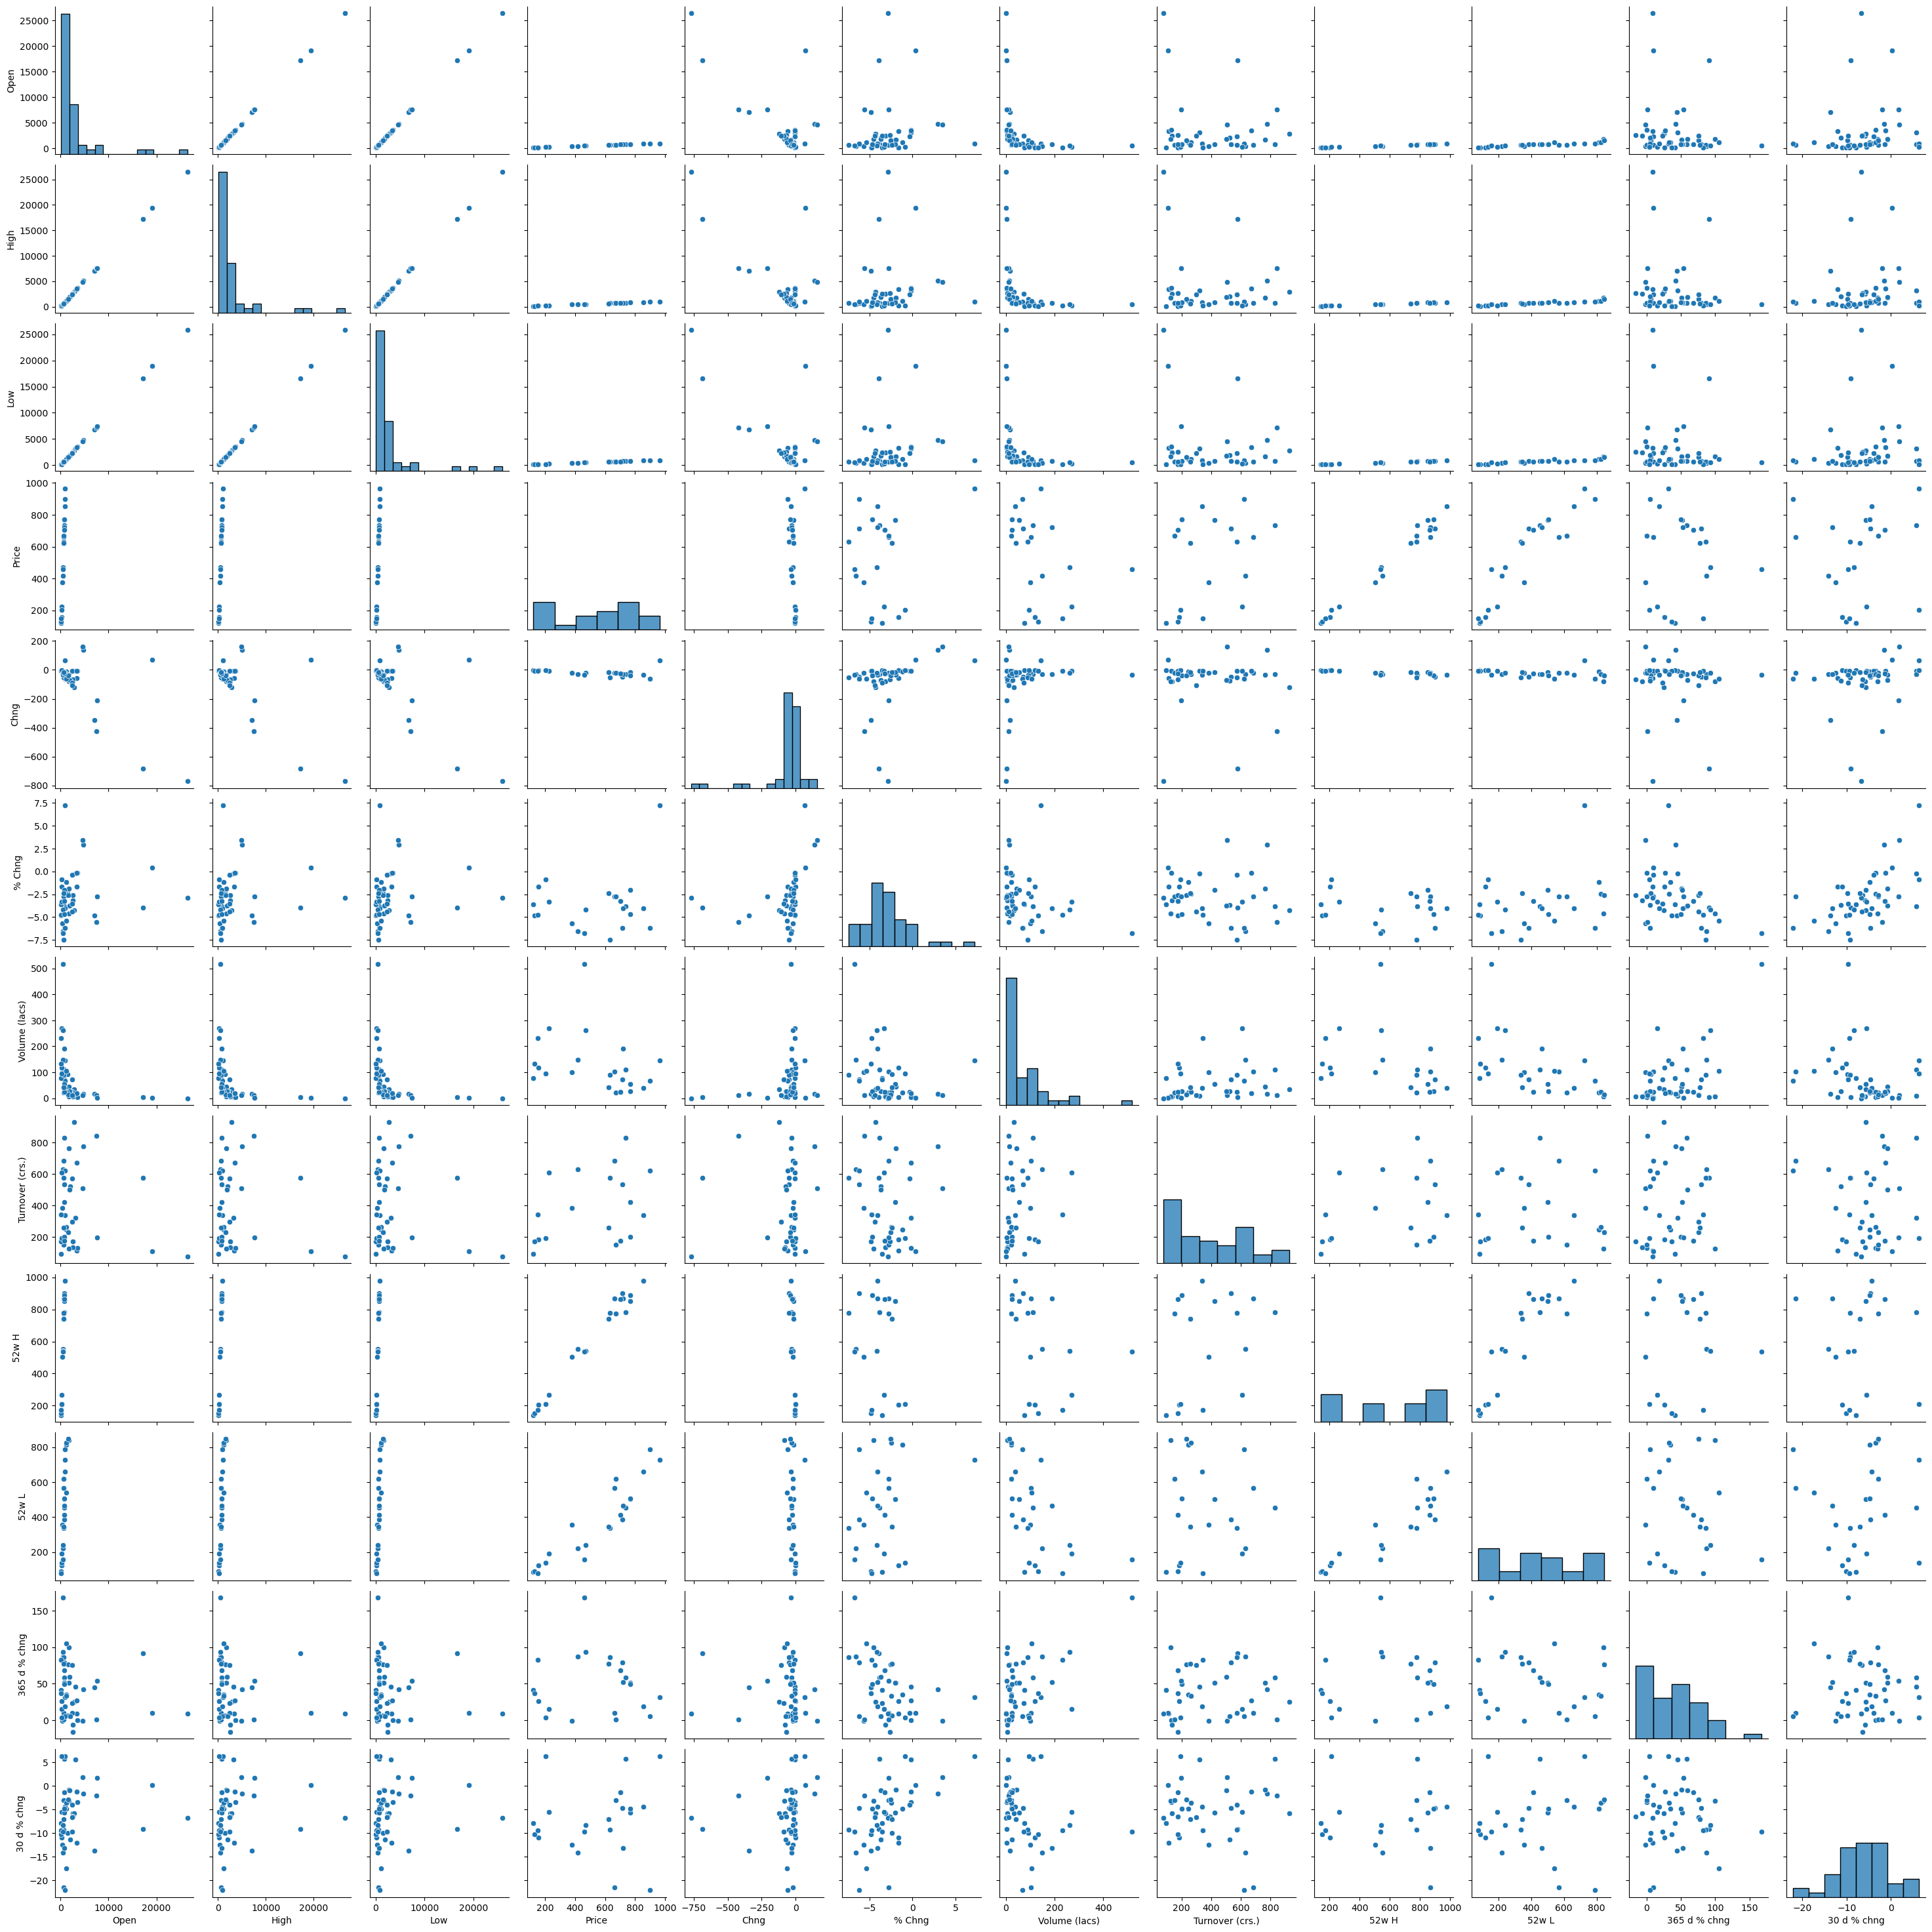

In [19]:
sns.pairplot(df)

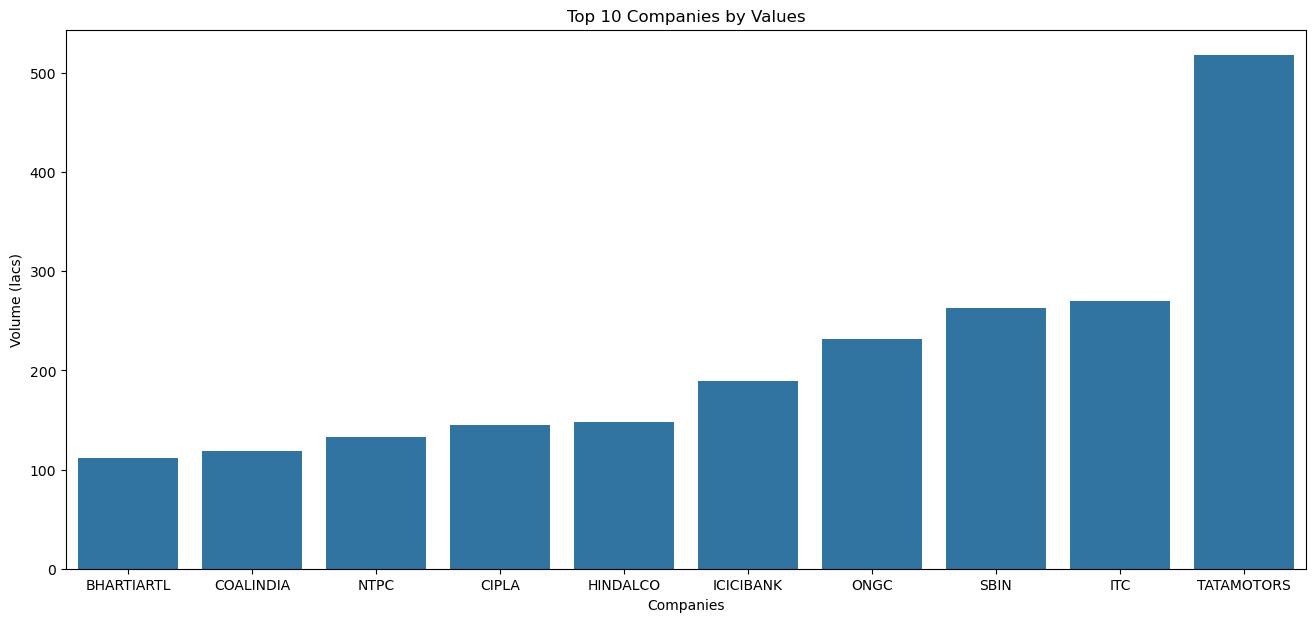

In [21]:
plt.figure(figsize = (16,7))


sns.barplot(data = df.sort_values(by = ['Volume (lacs)'], ascending = True).tail(10), x = 'Company', y = 'Volume (lacs)')
plt.xlabel("Companies")
plt.title("Top 10 Companies by Values")
plt.show()

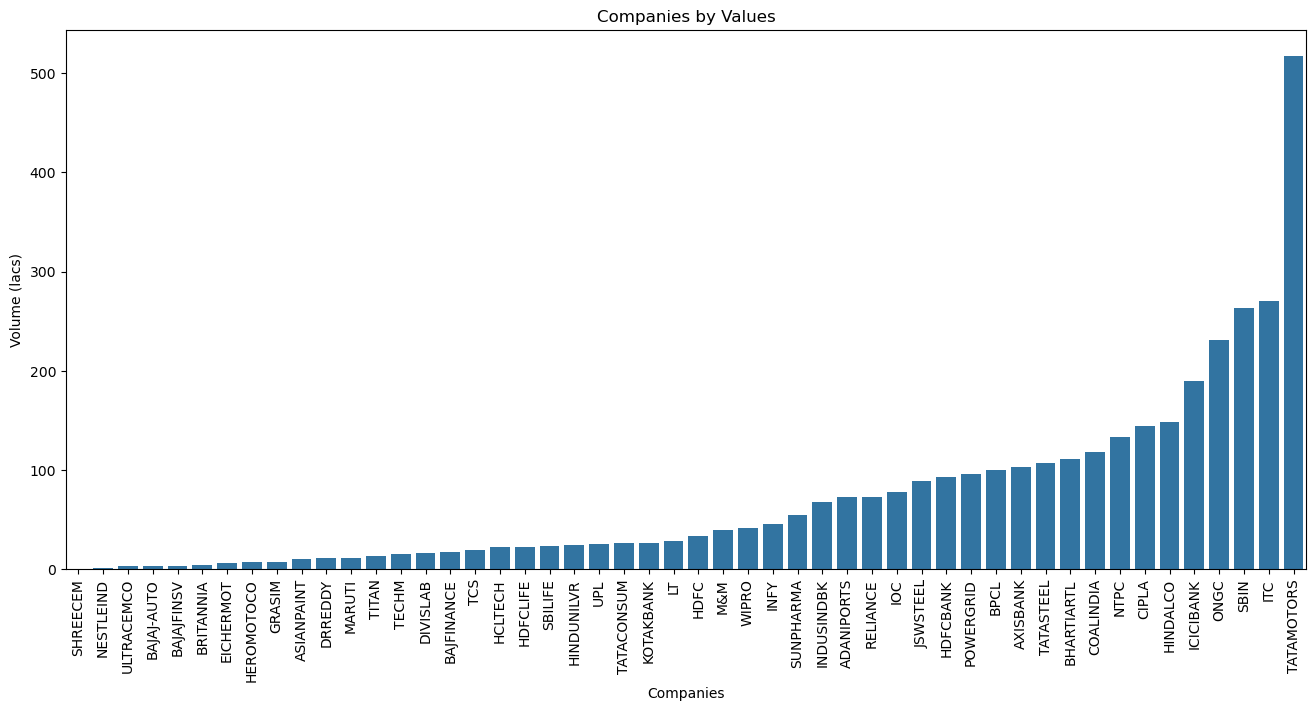

In [22]:
plt.figure(figsize = (16,7))
plt.xticks(rotation = 90)


sns.barplot(data = df.sort_values(by = ['Volume (lacs)'], ascending = True), x = 'Company', y = 'Volume (lacs)')
plt.xlabel("Companies")
plt.title("Companies by Values")
plt.show()

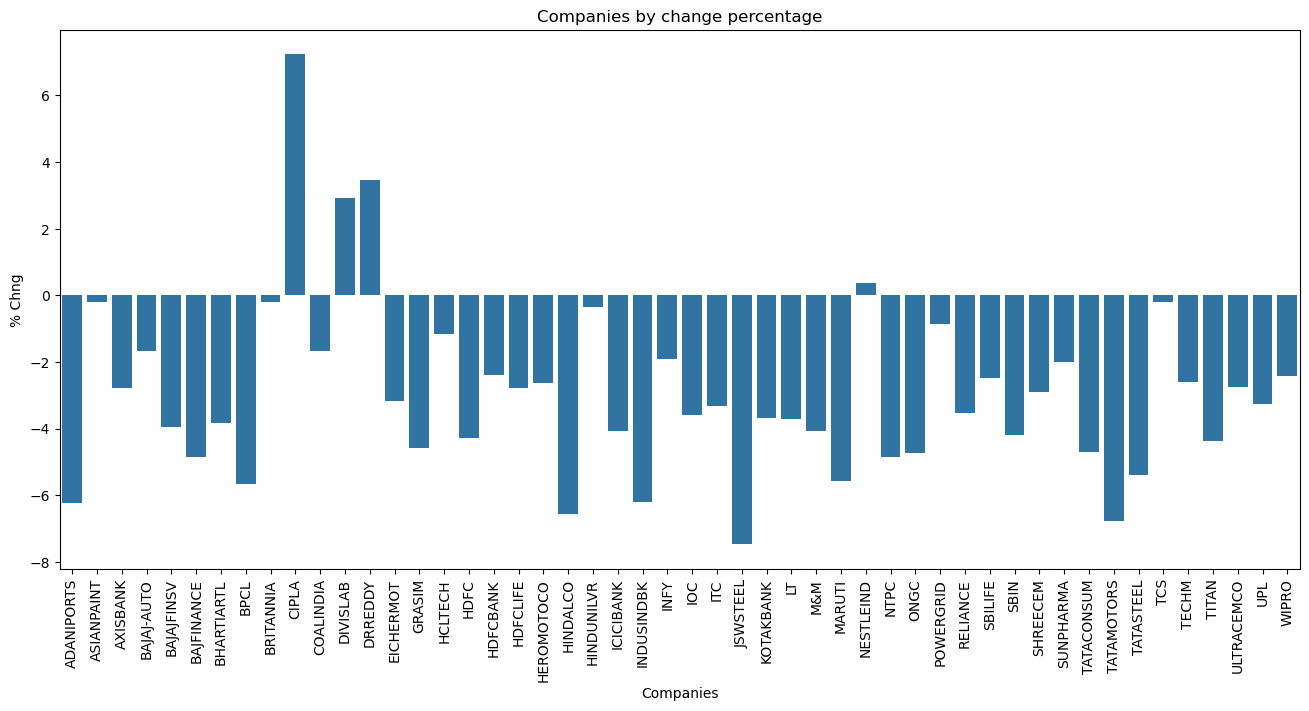

In [23]:
plt.figure(figsize = (16,7))
plt.xticks(rotation = 90)

sns.barplot(data = df, x = 'Company', y = '% Chng')
plt.xlabel("Companies")
plt.title("Companies by change percentage")
plt.show()

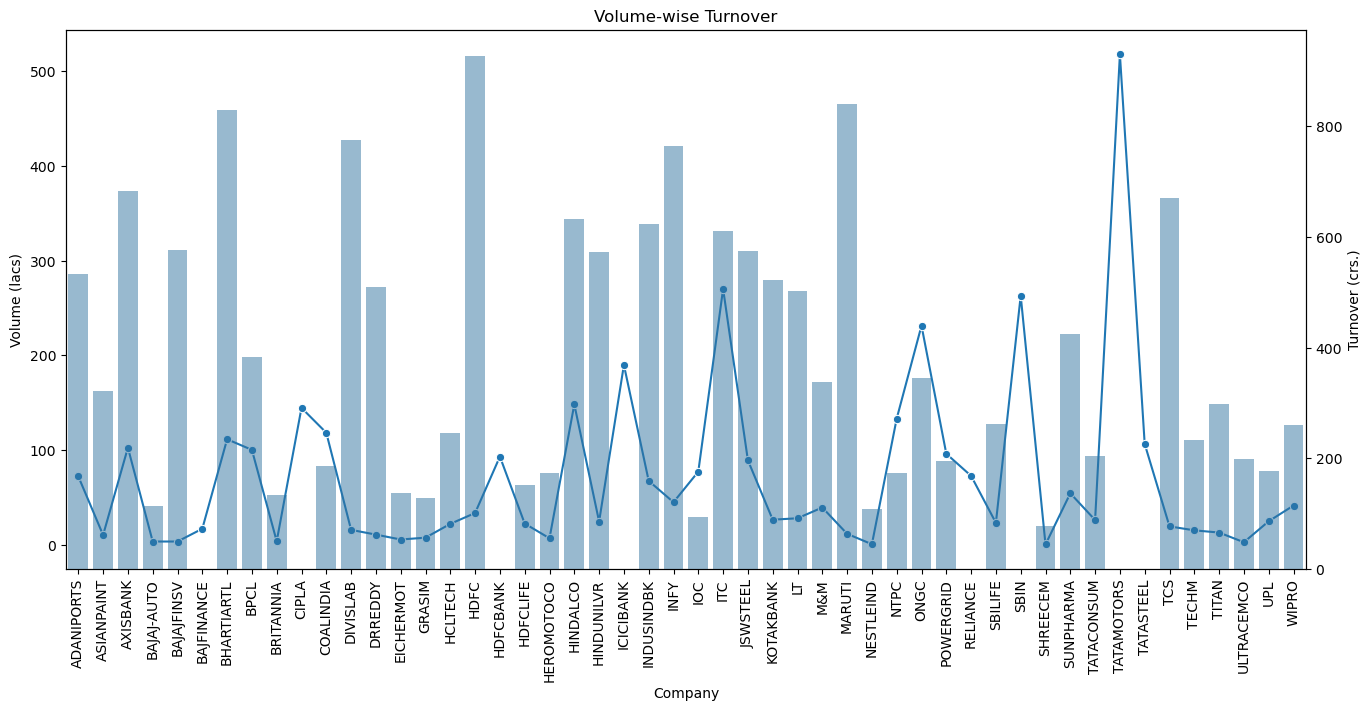

In [24]:
fig, ax1 = plt.subplots(figsize=(16,7))
plt.xticks(rotation = 90)
sns.lineplot(data = df, x = 'Company', y = 'Volume (lacs)', marker='o', sort = False, ax=ax1)
ax2 = ax1.twinx()
sns.barplot(data = df, x = 'Company', y = 'Turnover (crs.)', alpha=0.5, ax=ax2)
plt.xlabel('Companies')
plt.title('Volume-wise Turnover')
plt.show()

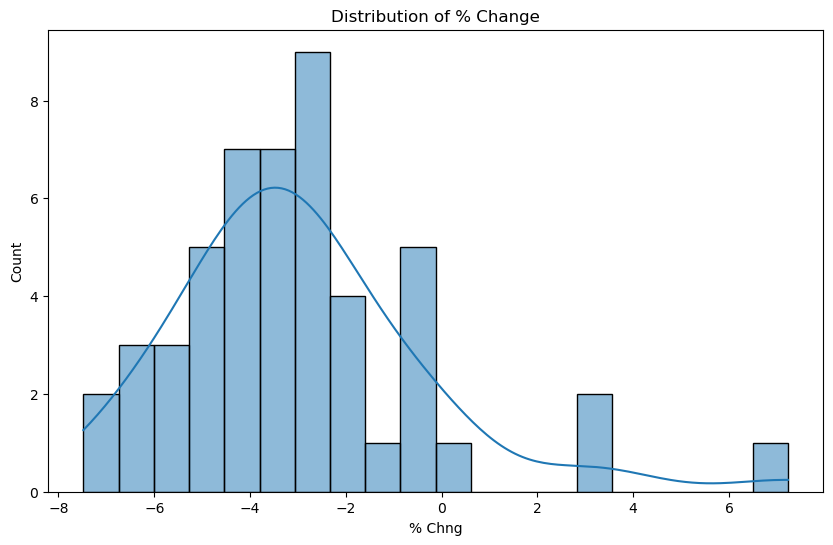

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot distribution of % Change
plt.figure(figsize=(10, 6))
sns.histplot(df['% Chng'], bins=20, kde=True)
plt.title('Distribution of % Change')
plt.show()

In [25]:
# Create a new feature for the range between 52-week high and low
df['52w Range'] = df['52w H'] - df['52w L']

# Log transformation of Volume and Turnover if they have large range
df['Volume (lacs)'] = df['Volume (lacs)'].apply(lambda x: np.log1p(x))
df['Turnover (crs.)'] = df['Turnover (crs.)'].apply(lambda x: np.log1p(x))

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop(columns=['Company', '% Chng'])
y = df['% Chng']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 1.0753545809999978
R^2 Score: 0.18338808701681208


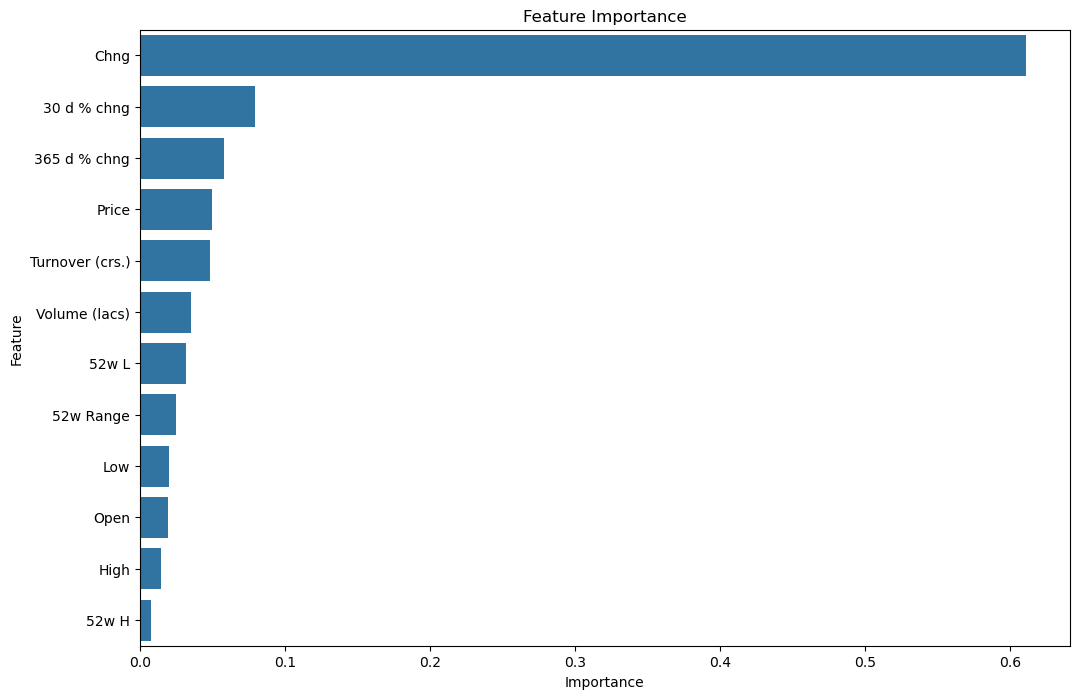

In [29]:
# Feature importance
importance = model.feature_importances_
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importance})

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.sort_values(by='Importance', ascending=False))
plt.title('Feature Importance')
plt.show()
